In [1]:
pip install numpy pandas matplotlib scikit-learn umap-learn requests

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached numba-0.66.0-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cache


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as MDA
from sklearn.manifold import Isomap, TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, accuracy_score
from sklearn.svm import SVC
import umap

d:\数学建模相关\python代码\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
# ====================== 1. 加载UCI BRCA基因数据集 ======================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00401/BRCA_tumor_normal.csv"
response = requests.get(url)
df = pd.read_csv(StringIO(response.text))

# 拆分特征与标签：最后一列为标签y(0正常/1肿瘤)，前面20531列为基因特征X
X_raw = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
print(f"原始数据形状：样本{X_raw.shape[0]}，基因特征{X_raw.shape[1]}")
print(f"类别分布：正常样本{(y==0).sum()}，肿瘤样本{(y==1).sum()}")


原始数据形状：样本0，基因特征0
类别分布：正常样本0，肿瘤样本0


In [ ]:
# ====================== 2. 统一预处理 ======================
imputer = SimpleImputer(strategy="mean")
X_fill = imputer.fit_transform(X_raw)
scaler = StandardScaler()
X = scaler.fit_transform(X_fill)

# 降维维度设置
vis_dim = 2    # 可视化2维
eval_dim = 10  # 定量评价10维

In [14]:
# ====================== 3. 无监督算法模型定义 ======================
# 2维可视化模型
unsup_2d = {
    "PCA": PCA(n_components=vis_dim, random_state=42),
    "KPCA": KernelPCA(n_components=vis_dim, kernel="rbf", gamma=1e-4, random_state=42),
    "ISOMAP": Isomap(n_components=vis_dim, n_neighbors=10),
    "t-SNE": TSNE(n_components=vis_dim, perplexity=30, random_state=42, method="barnes_hut"),
    "UMAP": umap.UMAP(n_components=vis_dim, n_neighbors=15, min_dist=0.1, random_state=42)
}
# 10维评价模型：t-SNE切换method="exact"支持高于3维
unsup_10d = {
    "PCA": PCA(n_components=eval_dim, random_state=42),
    "KPCA": KernelPCA(n_components=eval_dim, kernel="rbf", gamma=1e-4, random_state=42),
    "ISOMAP": Isomap(n_components=eval_dim, n_neighbors=10),
    "t-SNE": TSNE(n_components=eval_dim, perplexity=30, random_state=42, method="exact"),
    "UMAP": umap.UMAP(n_components=eval_dim, n_neighbors=15, min_dist=0.1, random_state=42)
}

result_table = {}
vis_embedding = {}

In [ ]:
# ---------------------- 4. 循环运行5个无监督算法 ----------------------
for name, model_2d in unsup_2d.items():
    print(f"\n==== 正在运行 {name} ====")
    t_start = time.time()
    embed_2d = model_2d.fit_transform(X)
    embed_10d = unsup_10d[name].fit_transform(X)
    run_time = round(time.time() - t_start, 3)
    vis_embedding[name] = embed_2d

    sc = silhouette_score(embed_10d, y)
    dbi = davies_bouldin_score(embed_10d, y)
    svm = SVC(kernel="rbf")
    svm.fit(embed_10d, y)
    acc = accuracy_score(y, svm.predict(embed_10d))

    result_table[name] = {
        "运行时间(s)": run_time,
        "轮廓系数SC": round(sc, 4),
        "DBI指数": round(dbi, 4),
        "SVM分类准确率": round(acc, 4)
    }



==== 正在运行 PCA ====

==== 正在运行 KPCA ====

==== 正在运行 ISOMAP ====


d:\数学建模相关\python代码\.venv\Lib\site-packages\sklearn\manifold\_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
d:\数学建模相关\python代码\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
d:\数学建模相关\python代码\.venv\Lib\site-packages\sklearn\manifold\_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
d:\数学建模相关\python代码\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self.


==== 正在运行 t-SNE ====

==== 正在运行 UMAP ====


d:\数学建模相关\python代码\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\数学建模相关\python代码\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# ---------------------- 5. 单独处理监督降维MDA ----------------------
print("\n==== 正在运行 MDA ====")
t_start_mda = time.time()
mda_model = MDA(n_components=1)
embed_1d = mda_model.fit_transform(X, y)
# 绘图用2维
embed_mda_2d = np.concatenate([embed_1d, embed_1d], axis=1)
# 评价10维
embed_mda_10d = np.repeat(embed_1d, repeats=10, axis=1)
mda_time = round(time.time() - t_start_mda, 3)

sc_mda = silhouette_score(embed_mda_10d, y)
dbi_mda = davies_bouldin_score(embed_mda_10d, y)
svm_mda = SVC(kernel="rbf")
svm_mda.fit(embed_mda_10d, y)
acc_mda = accuracy_score(y, svm_mda.predict(embed_mda_10d))

vis_embedding["MDA"] = embed_mda_2d
result_table["MDA"] = {
    "运行时间(s)": mda_time,
    "轮廓系数SC": round(sc_mda, 4),
    "DBI指数": round(dbi_mda, 4),
    "SVM分类准确率": round(acc_mda, 4)
}


==== 正在运行 MDA ====



========== 六种降维算法量化对比结果 ==========
        运行时间(s)  轮廓系数SC   DBI指数  SVM分类准确率
PCA       0.785  0.8799  0.1695    1.0000
KPCA      1.020  0.7003  0.4484    1.0000
ISOMAP    2.122  0.7026  0.4350    1.0000
t-SNE    57.520  0.1449  2.2974    0.9992
UMAP     29.584  0.9416  0.0837    1.0000
MDA       6.828  0.8870  0.1567    1.0000


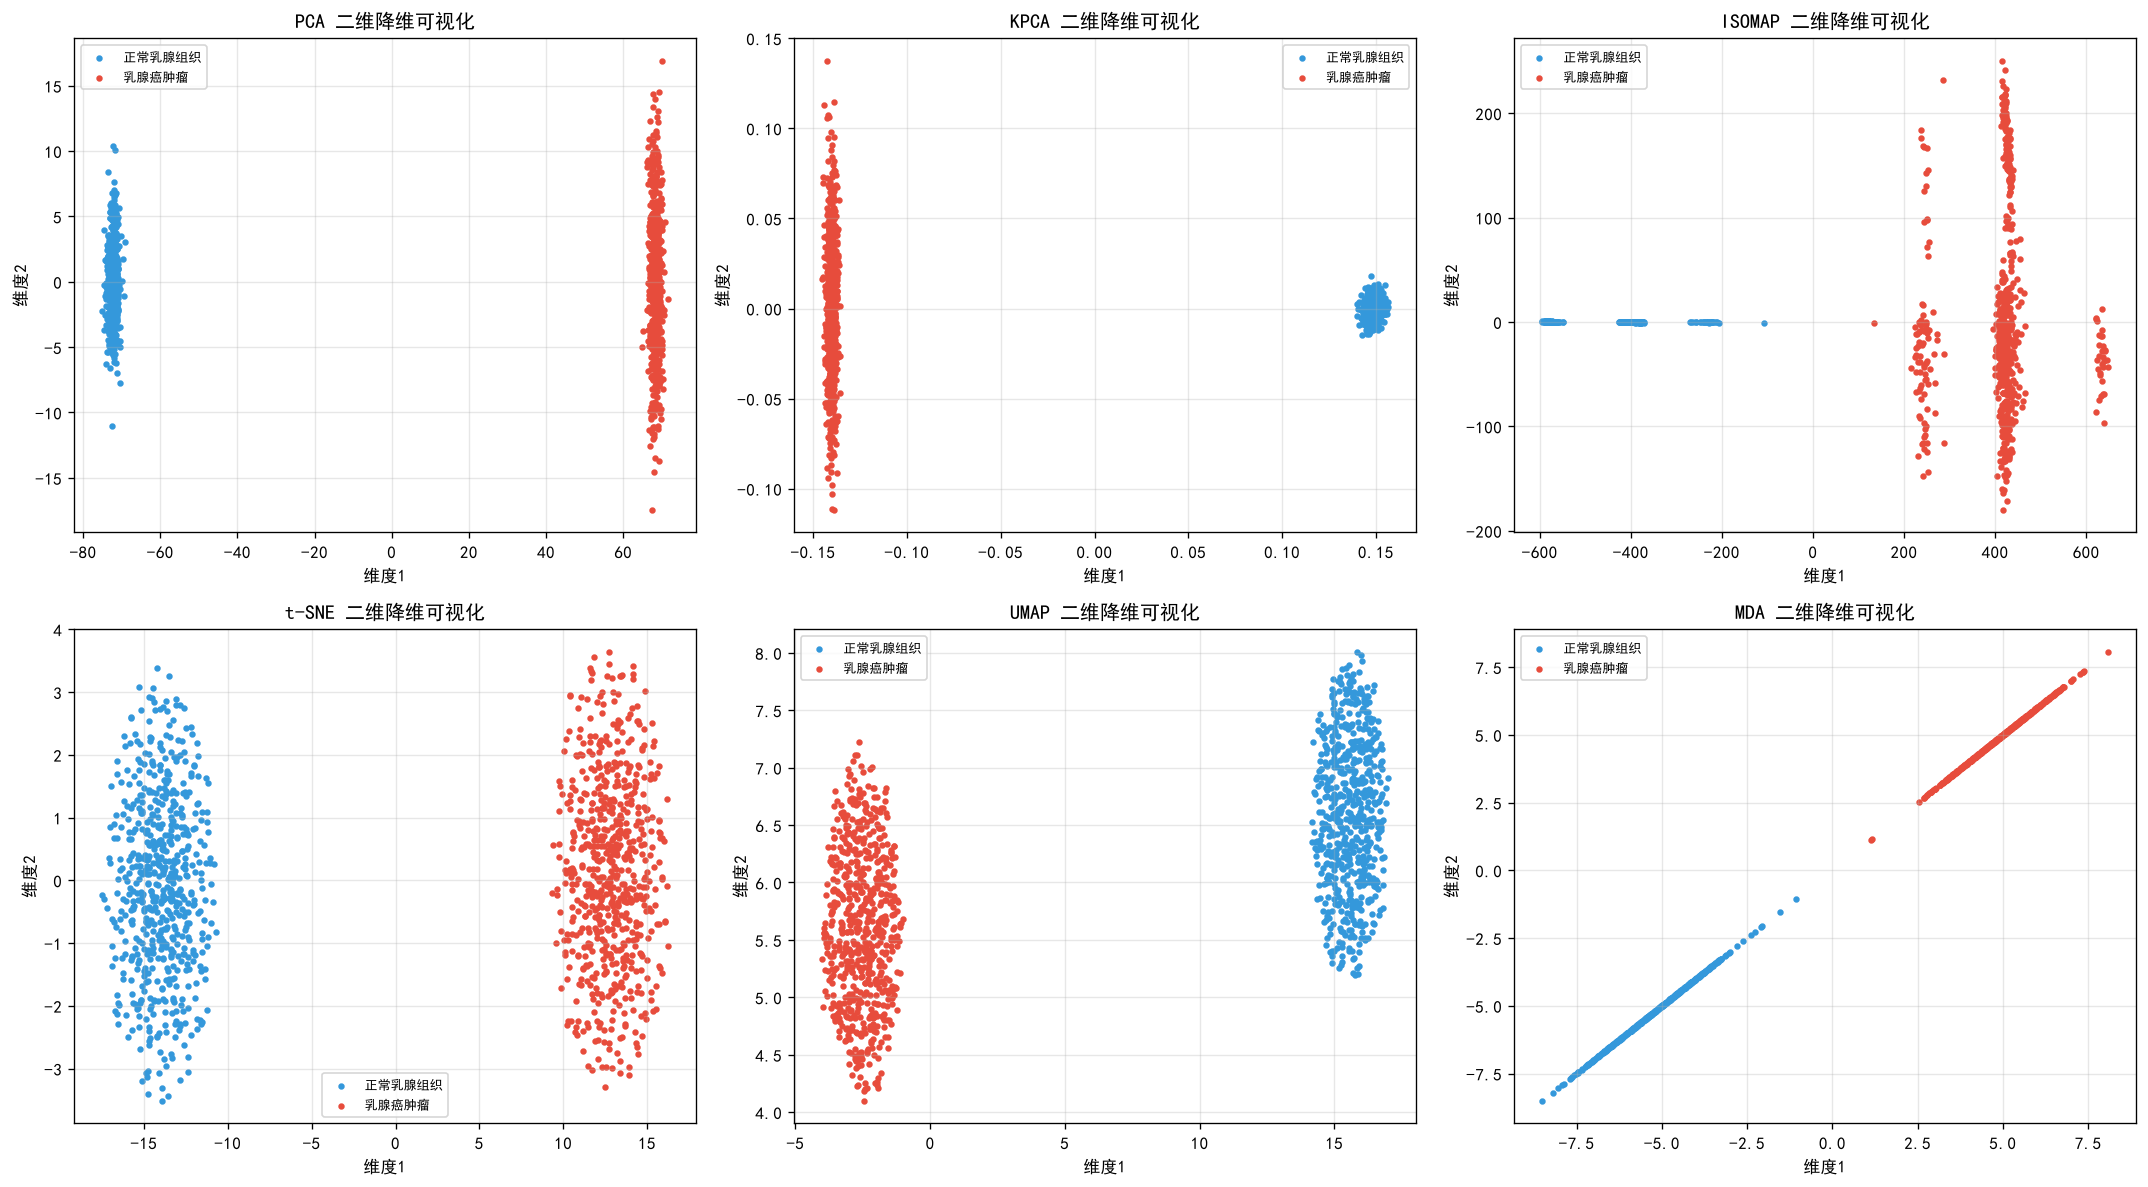

In [ ]:
# ---------------------- 5. 输出降维算法对比图 ----------------------
res_df = pd.DataFrame(result_table).T
print("\n========== 六种降维算法量化对比结果 ==========")
print(res_df)

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=120)
axes = axes.flatten()
colors = ["#3498db", "#e74c3c"]
plot_order = ["PCA", "KPCA", "ISOMAP", "t-SNE", "UMAP", "MDA"]

for idx, alg_name in enumerate(plot_order):
    ax = axes[idx]
    embed = vis_embedding[alg_name]
    mask_0 = y == 0
    mask_1 = y == 1
    ax.scatter(embed[mask_0, 0], embed[mask_0, 1], s=8, c=colors[0], label="正常乳腺组织")
    ax.scatter(embed[mask_1, 0], embed[mask_1, 1], s=8, c=colors[1], label="乳腺癌肿瘤")
    ax.set_title(f"{alg_name} 二维降维可视化", fontsize=12)
    ax.set_xlabel("维度1")
    ax.set_ylabel("维度2")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("降维算法对比图.png", dpi=150, bbox_inches="tight")
plt.show()

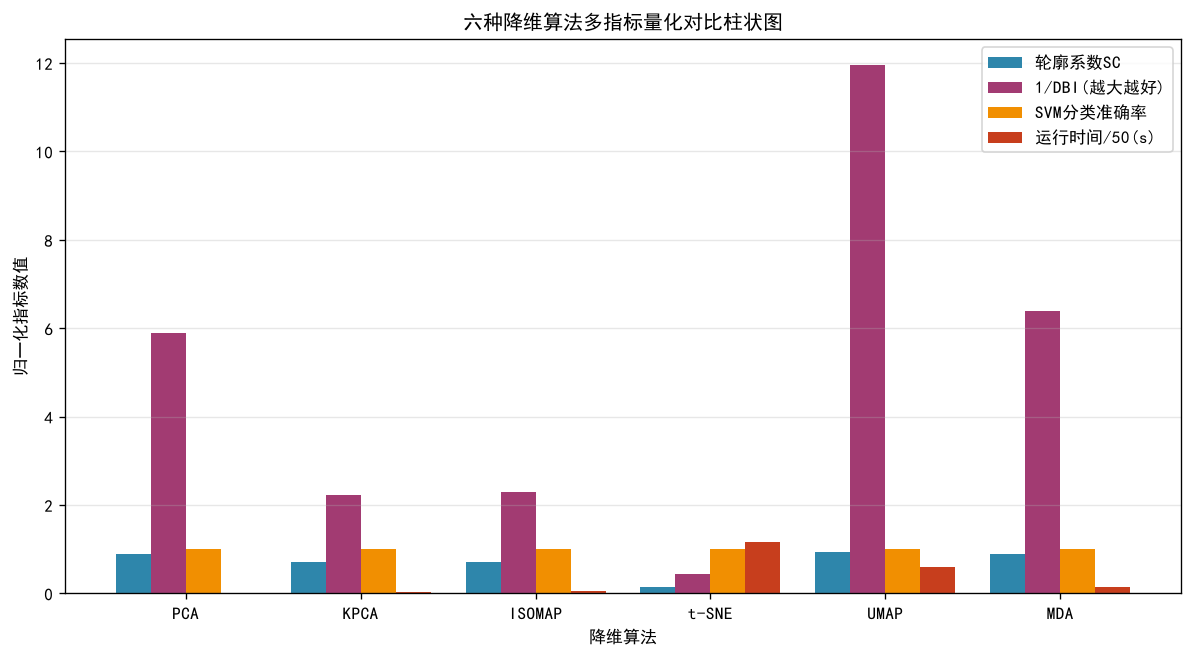

In [ ]:
from scipy.stats import gaussian_kde

# ---------------------- 6. 指标分组柱状对比图 ----------------------
plt.figure(figsize=(12,6),dpi=120)
alg_names = list(result_table.keys())
sc_scores = [result_table[name]["轮廓系数SC"] for name in alg_names]
dbi_scores = [result_table[name]["DBI指数"] for name in alg_names]
acc_scores = [result_table[name]["SVM分类准确率"] for name in alg_names]
time_cost = [result_table[name]["运行时间(s)"] for name in alg_names]

x = np.arange(len(alg_names))
width = 0.2
plt.bar(x-1.5*width, sc_scores, width, label="轮廓系数SC", color="#2E86AB")
plt.bar(x-0.5*width, 1/np.array(dbi_scores), width, label="1/DBI(越大越好)", color="#A23B72")
plt.bar(x+0.5*width, acc_scores, width, label="SVM分类准确率", color="#F18F01")
plt.bar(x+1.5*width, np.array(time_cost)/50, width, label="运行时间/50(s)", color="#C73E1D")
plt.xticks(x, alg_names)
plt.xlabel("降维算法")
plt.ylabel("归一化指标数值")
plt.title("六种降维算法多指标量化对比柱状图")
plt.legend()
plt.grid(axis="y",alpha=0.3)
plt.savefig("指标柱状对比图.png",dpi=150,bbox_inches="tight")
plt.show()

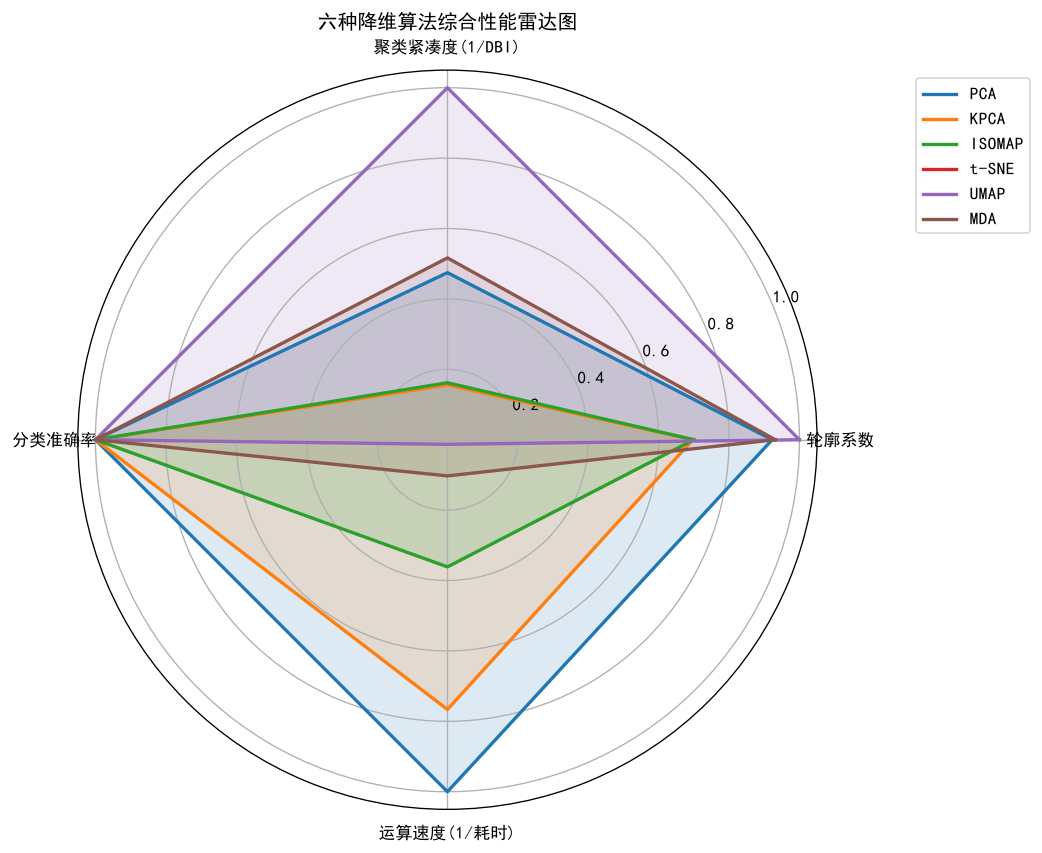

In [ ]:
# ---------------------- 7. 雷达图 ----------------------
from math import pi
# 指标归一化到0-1
def norm(arr):
    return (arr-np.min(arr))/(np.max(arr)-np.min(arr))
sc_norm = norm(np.array(sc_scores))
dbi_norm = norm(1/np.array(dbi_scores))
acc_norm = norm(np.array(acc_scores))
speed_norm = norm(1/np.array(time_cost))
metrics = ["轮廓系数","聚类紧凑度(1/DBI)","分类准确率","运算速度(1/耗时)"]
metric_num = len(metrics)
angles = [n / float(metric_num)*2*pi for n in range(metric_num)]
angles += angles[:1]

fig,ax = plt.subplots(figsize=(8,8),subplot_kw={"projection":"polar"},dpi=120)
colors_radar = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]
for idx,alg in enumerate(alg_names):
    vals = [sc_norm[idx],dbi_norm[idx],acc_norm[idx],speed_norm[idx]]
    vals += vals[:1]
    ax.plot(angles,vals,label=alg,color=colors_radar[idx],linewidth=2)
    ax.fill(angles,vals,alpha=0.15,color=colors_radar[idx])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_title("六种降维算法综合性能雷达图")
ax.legend(loc="upper right",bbox_to_anchor=(1.3,1))
plt.savefig("综合性能雷达图.png",dpi=150,bbox_inches="tight")
plt.show()

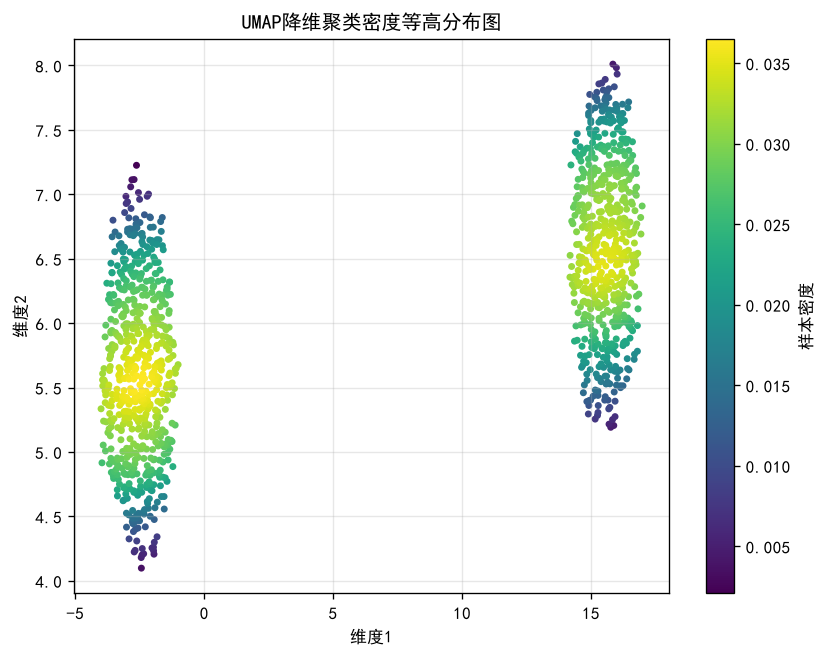

In [ ]:
# ---------------------- 8. UMAP密度等高聚类图 ----------------------
plt.figure(figsize=(8,6),dpi=120)
embed_umap = vis_embedding["UMAP"]
x_um,y_um = embed_umap[:,0],embed_umap[:,1]
# 核密度计算
xy = np.vstack([x_um,y_um])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x_um,y_um,z = x_um[idx],y_um[idx],z[idx]
scatter = plt.scatter(x_um,y_um,c=z,cmap="viridis",s=10)
plt.colorbar(scatter,label="样本密度")
plt.title("UMAP降维聚类密度等高分布图")
plt.xlabel("维度1")
plt.ylabel("维度2")
plt.grid(alpha=0.3)
plt.savefig("UMAP密度等高图.png",dpi=150,bbox_inches="tight")
plt.show()